# Pitching airfoil Visualization

This notebook can compare one or two pitching-airfoil results side by side.

- flow fields: `ux`, `uy`, `|u|`, vorticity
- force history: `Cd`, `Cl`, and late-time zoom
- lift spectrum overlay

The default configuration below points to the current saved pitching-airfoil run.


In [1]:
from pathlib import Path
import math
import re

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import yt
yt.set_log_level("error")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


def parse_inputs(inputs_path: Path):
    keys = {'ibm.x0': None, 'ibm.y0': None, 'lbmPhysicalParameters.U0': None}
    with inputs_path.open() as fh:
        for raw in fh:
            line = raw.split('#', 1)[0].strip()
            if not line or '=' not in line:
                continue
            lhs, rhs = [part.strip() for part in line.split('=', 1)]
            if lhs in keys:
                keys[lhs] = float(rhs.split()[0])
    missing = [k for k, v in keys.items() if v is None]
    if missing:
        raise RuntimeError(f'Missing inputs keys in {inputs_path}: {missing}')
    return {k: float(v) for k, v in keys.items()}


def parse_header_constants(path: Path):
    names = [
        'airfoil_chord',
        'airfoil_thickness',
        'pitch_mean',
        'pitch_amplitude',
        'pitch_frequency',
        'pitch_phase',
    ]
    text = path.read_text()
    vals = {}
    for name in names:
        m = re.search(rf"{name}\s*=\s*amrex::Real\(([-+0-9.eE]+)\)", text)
        if not m:
            raise RuntimeError(f'Could not parse {name} from {path}')
        vals[name] = float(m.group(1))
    return vals


def latest_plotfile(root: Path):
    cands = []
    for p in root.glob('plt*'):
        if p.is_dir() and re.fullmatch(r'plt\d+', p.name):
            cands.append(p)
    if not cands:
        raise FileNotFoundError(f'No plotfiles found under {root}')
    cands.sort()
    return cands[-1]


def list_plotfiles(root: Path):
    cands = []
    for p in root.glob('plt*'):
        if p.is_dir() and re.fullmatch(r'plt\d+', p.name):
            cands.append(p)
    if not cands:
        raise FileNotFoundError(f'No plotfiles found under {root}')
    cands.sort()
    return cands


def finest_covering_grid(ds):
    level = int(ds.index.max_level)
    dims = np.array(ds.domain_dimensions, dtype=np.int64)
    if level > 0:
        ref = int(np.prod(np.asarray(ds.ref_factors[:level], dtype=np.int64)))
        dims *= ref
    ds.force_periodicity()
    return ds.smoothed_covering_grid(
        level=level,
        left_edge=ds.domain_left_edge,
        dims=tuple(int(v) for v in dims),
        num_ghost_zones=0,
    )


def load_fields2d(plotfile: Path):
    ds = yt.load(str(plotfile))
    cg = finest_covering_grid(ds)

    def field(name):
        arr = cg[('boxlib', name)].to_ndarray()
        if arr.ndim == 3:
            arr = arr[:, :, arr.shape[2] // 2]
        return np.asarray(arr, dtype=np.float64)

    extent = [
        float(ds.domain_left_edge[0]),
        float(ds.domain_right_edge[0]),
        float(ds.domain_left_edge[1]),
        float(ds.domain_right_edge[1]),
    ]
    return ds, extent, field('ux'), field('uy'), field('vor')


def vorticity_quantile_limit(plotfiles, quantile=0.995):
    vmax = 0.0
    for plotfile in plotfiles:
        _, _, _, _, vor = load_fields2d(plotfile)
        local = float(np.quantile(np.abs(vor), quantile))
        vmax = max(vmax, local)
    return max(vmax, 1.0e-12)


def pitch_angle(t_conv, par):
    return par['pitch_mean'] + par['pitch_amplitude'] * np.sin(2.0 * np.pi * t_conv + par['pitch_phase'])


def airfoil_outline(x0, y0, chord, thickness, angle, n_half=200):
    beta = np.linspace(0.0, math.pi, n_half + 1)
    x = 0.5 * chord * (1.0 - np.cos(beta))
    xc = np.clip(x / chord, 0.0, 1.0)
    yt = 5.0 * thickness * chord * (
        0.2969 * np.sqrt(xc)
        - 0.1260 * xc
        - 0.3516 * xc * xc
        + 0.2843 * xc * xc * xc
        - 0.1036 * xc * xc * xc * xc
    )
    xr = np.concatenate([x, x[-2:0:-1]])
    yr = np.concatenate([yt, -yt[-2:0:-1]])
    c = math.cos(angle)
    s = math.sin(angle)
    xp = x0 + c * xr - s * yr
    yp = y0 + s * xr + c * yr
    return xp, yp


def add_airfoil(ax, x0, y0, chord, thickness, angle):
    xp, yp = airfoil_outline(x0, y0, chord, thickness, angle)
    ax.fill(xp, yp, facecolor='black', edgecolor='white', linewidth=0.7)


def _parse_floats(line):
    vals = []
    for tok in line.split():
        try:
            vals.append(float(tok))
        except ValueError:
            pass
    return vals


def load_force(path: Path):
    rows = []
    with path.open('rb') as fh:
        for raw in fh:
            line = raw.decode('ascii', errors='ignore').replace('\x00', ' ').strip()
            if not line or line.startswith('#'):
                continue
            vals = _parse_floats(line)
            if len(vals) < 6:
                continue
            rows.append(vals)

    if not rows:
        raise RuntimeError(f'No readable force rows found in {path}')

    ncols = max(len(r) for r in rows)
    if ncols < 22:
        raise RuntimeError(f'Unexpected force format in {path}: max columns = {ncols}')

    t = np.asarray([r[22] if len(r) > 22 else r[1] for r in rows], dtype=np.float64)
    cd = np.asarray([r[20] if len(r) > 20 else r[4] for r in rows], dtype=np.float64)
    cl = np.asarray([r[21] if len(r) > 21 else r[5] for r in rows], dtype=np.float64)
    return t, cd, cl


def trimmed_ylim(y, ignore_frac=0.05, pad_frac=0.08):
    n = len(y)
    start = min(max(int(ignore_frac * n), 0), max(n - 1, 0))
    core = y[start:]
    lo = float(np.min(core))
    hi = float(np.max(core))
    span = max(hi - lo, 1.0e-8)
    pad = pad_frac * span
    return (lo - pad, hi + pad), start


def combined_trimmed_ylim(series_list, ignore_frac=0.05, pad_frac=0.08):
    los = []
    his = []
    starts = []
    for y in series_list:
        (lo, hi), start = trimmed_ylim(y, ignore_frac=ignore_frac, pad_frac=pad_frac)
        los.append(lo)
        his.append(hi)
        starts.append(start)
    return (min(los), max(his)), starts


/home/haotian/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
INPUTS_FILE = Path('inputs')
GEOM_FILE = Path('IBMUserDefinedGeometry.H')
CD_YLIM_IGNORE_FRAC = 0.05
TAIL_FRAC = 0.30
VORTICITY_CLIM = 0.01  # fixed to match movie vorticity color scale

CASES = [
    {
        'label': 'Pitching airfoil 19 periods (dense)',
        'plot_root': Path('out_pitching_airfoil_19T_dense'),
        'force_file': Path('_artifacts/force_19T_dense.dat'),
    },
]

inp = parse_inputs(INPUTS_FILE)
par = parse_header_constants(GEOM_FILE)
x0 = inp['ibm.x0']
y0 = inp['ibm.y0']
chord = par['airfoil_chord']
thickness = par['airfoil_thickness']

loaded_cases = []
for case in CASES:
    plot_root = Path(case['plot_root'])
    force_file = Path(case['force_file'])
    if not plot_root.exists():
        print(f"skip {case['label']}: missing plot root {plot_root}")
        continue
    if not force_file.exists():
        print(f"skip {case['label']}: missing force file {force_file}")
        continue

    all_plotfiles = list_plotfiles(plot_root)
    plotfile = all_plotfiles[-2] if len(all_plotfiles) > 1 else all_plotfiles[-1]
    t, cd, cl = load_force(force_file)
    loaded = dict(case)
    loaded['plotfile'] = plotfile
    loaded['t'] = t
    loaded['cd'] = cd
    loaded['cl'] = cl
    loaded_cases.append(loaded)

if not loaded_cases:
    raise RuntimeError('No cases could be loaded. Check the CASES paths in this cell.')

for case in loaded_cases:
    print(case['label'])
    print(f"  plotfile:   {case['plotfile']}")
    print(f"  force file: {case['force_file']}")
    print(f"  samples:    {len(case['t'])}")


Pitching airfoil 19 periods (dense)
  plotfile:   out_pitching_airfoil_19T_dense/plt12600
  force file: _artifacts/force_19T_dense.dat
  samples:    12667


## Airfoil Kinematics

The pitching motion is prescribed as
\[
\alpha(t) = \alpha_0 + \alpha_a \sin(2\pi f t + \phi),
\]
with \(f = U_\infty / c\).

Using convective time \(t^* = t U_\infty / c\), this becomes
\[
\alpha(t^*) = \alpha_0 + \alpha_a \sin(2\pi t^* + \phi).
\]
In this setup: \(\alpha_0=\texttt{pitch\_mean}\), \(\alpha_a=\texttt{pitch\_amplitude}\), and \(\phi=\texttt{pitch\_phase}\).

## Flow Fields

Each row is one case. Positive vorticity is red and negative vorticity is blue. The pitched NACA 0012 outline at the saved time is drawn on every panel.

Vorticity color limits are fixed at ±0.01 (same as the movie).


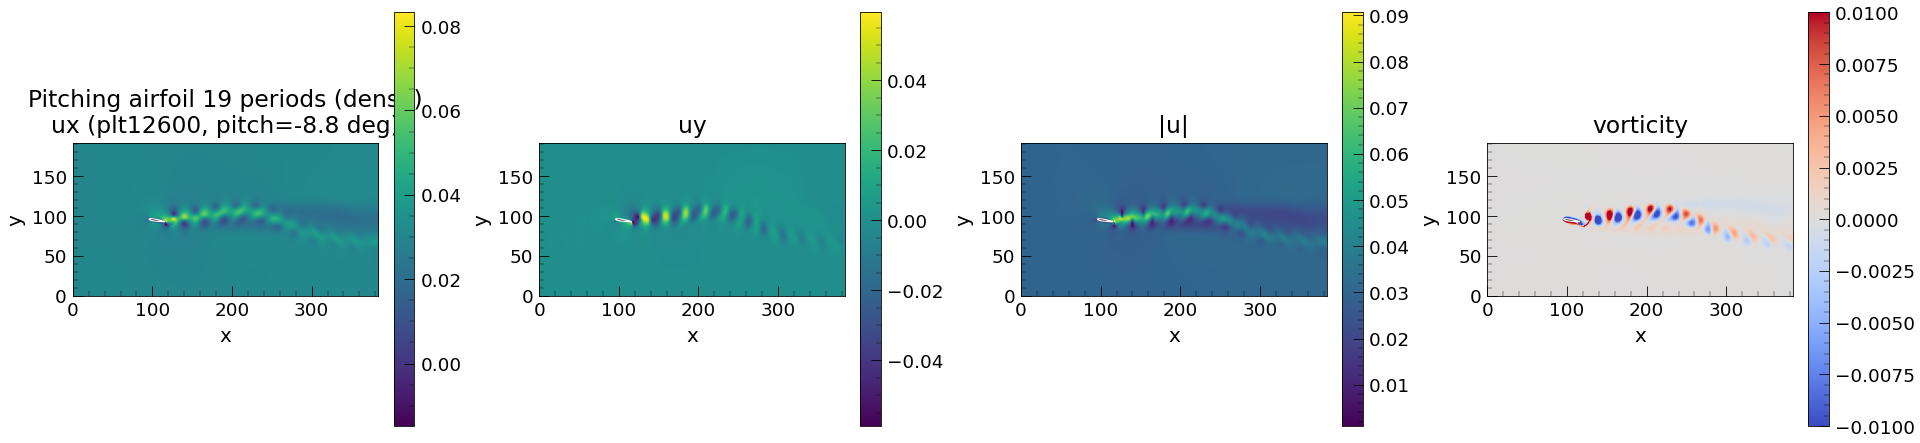

In [3]:
fig, ax = plt.subplots(len(loaded_cases), 4, figsize=(16, 4 * len(loaded_cases)), constrained_layout=True)
if len(loaded_cases) == 1:
    ax = np.asarray([ax])

for row, case in enumerate(loaded_cases):
    vor_norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-VORTICITY_CLIM, vmax=VORTICITY_CLIM)

    ds, extent, ux, uy, vor = load_fields2d(case['plotfile'])
    plot_step = int(case['plotfile'].name.replace('plt', ''))
    t_conv_plot = par['pitch_frequency'] * plot_step
    angle = float(pitch_angle(np.asarray([t_conv_plot]), par)[0])
    speed = np.sqrt(ux * ux + uy * uy)

    fields = [
        ('ux', ux, 'viridis', None),
        ('uy', uy, 'viridis', None),
        ('|u|', speed, 'viridis', None),
        ('vorticity', vor, 'coolwarm', vor_norm),
    ]
    for col, (name, arr, cmap, norm) in enumerate(fields):
        axi = ax[row, col]
        im = axi.imshow(arr.T, origin='lower', extent=extent, cmap=cmap, norm=norm, aspect='equal', interpolation='nearest')
        add_airfoil(axi, x0, y0, chord, thickness, angle)
        title = f"{case['label']}\n{name} ({case['plotfile'].name}, pitch={np.degrees(angle):.1f} deg)" if col == 0 else name
        axi.set_title(title)
        axi.set_xlabel('x')
        axi.set_ylabel('y')
        axi.grid(False)
        fig.colorbar(im, ax=axi, shrink=0.88)

plt.show()


## Force History

The `Cd` y-range ignores the startup spike when setting limits, so the later dynamics stay readable.


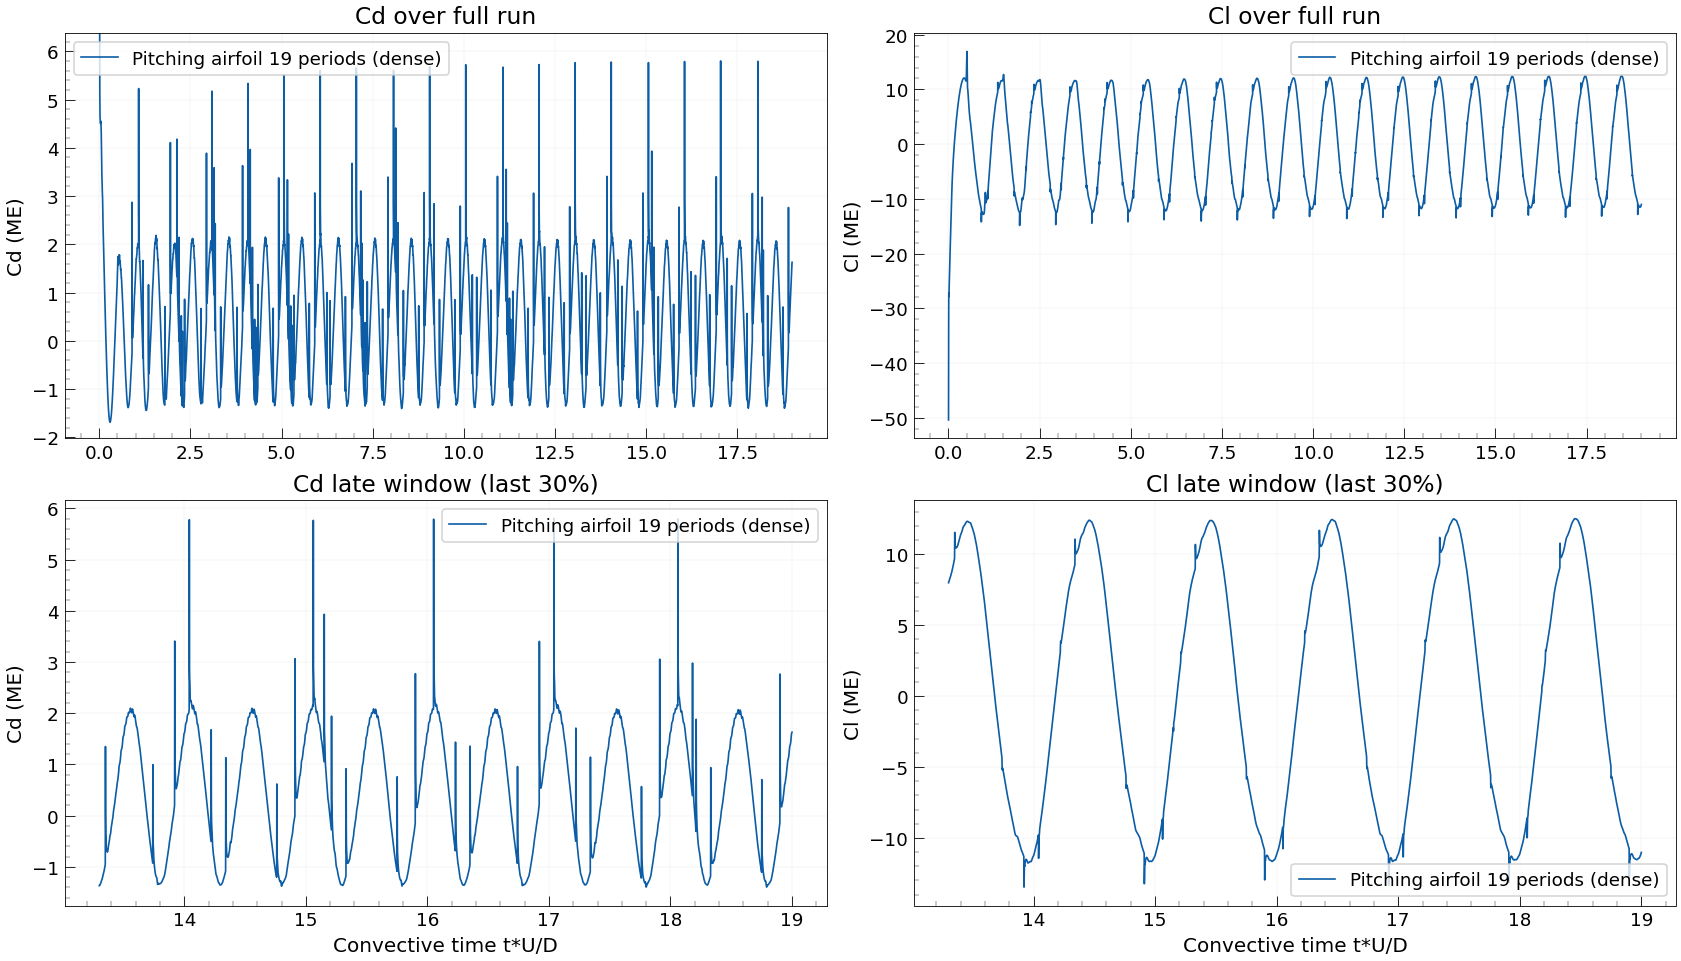

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
cd_ylim, _ = combined_trimmed_ylim([case['cd'] for case in loaded_cases], ignore_frac=CD_YLIM_IGNORE_FRAC)
cl_tail_ylim = None
cd_tail_ylim = None

for case in loaded_cases:
    t = case['t']
    cd = case['cd']
    cl = case['cl']
    tail_start = max(int((1.0 - TAIL_FRAC) * len(t)), 0)

    ax[0, 0].plot(t, cd, lw=1.0, label=case['label'])
    ax[0, 1].plot(t, cl, lw=1.0, label=case['label'])
    ax[1, 0].plot(t[tail_start:], cd[tail_start:], lw=1.0, label=case['label'])
    ax[1, 1].plot(t[tail_start:], cl[tail_start:], lw=1.0, label=case['label'])

ax[0, 0].set_title('Cd over full run')
ax[0, 0].set_ylabel('Cd (ME)')
ax[0, 0].set_ylim(*cd_ylim)
ax[0, 0].legend()

ax[0, 1].set_title('Cl over full run')
ax[0, 1].set_ylabel('Cl (ME)')
ax[0, 1].legend()

ax[1, 0].set_title(f'Cd late window (last {int(TAIL_FRAC * 100)}%)')
ax[1, 0].set_xlabel('Convective time t*U/D')
ax[1, 0].set_ylabel('Cd (ME)')
ax[1, 0].legend()

ax[1, 1].set_title(f'Cl late window (last {int(TAIL_FRAC * 100)}%)')
ax[1, 1].set_xlabel('Convective time t*U/D')
ax[1, 1].set_ylabel('Cl (ME)')
ax[1, 1].legend()

for axi in ax.ravel():
    axi.grid(alpha=0.25)

plt.show()


## Lift Spectrum

FFT overlay of the lift signal for a quick comparison of dominant shedding frequency.


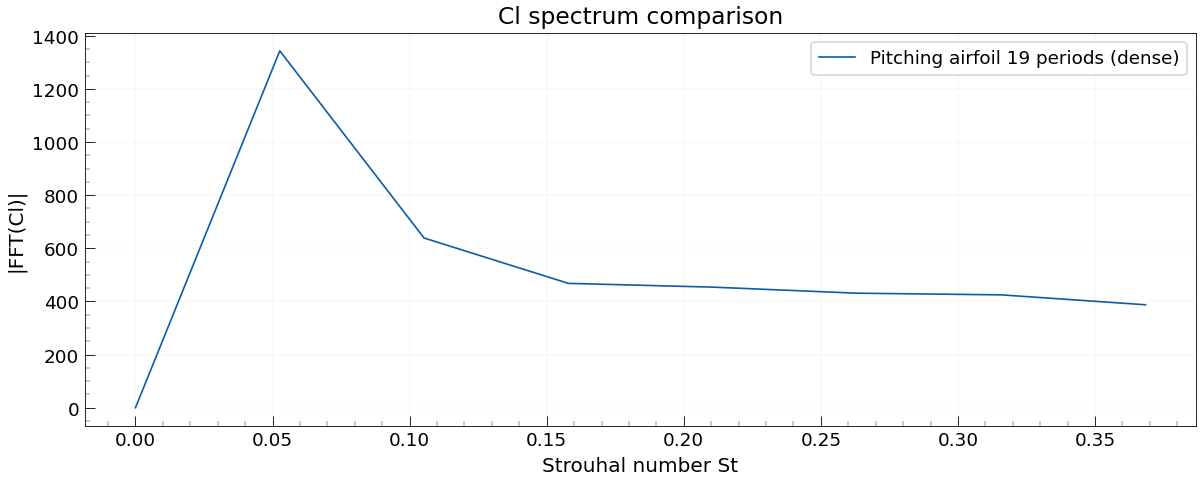

In [5]:
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

for case in loaded_cases:
    t = case['t']
    cl = case['cl']
    cl_centered = cl - np.mean(cl)
    dt = (t[-1] - t[0]) / max(len(t) - 1, 1)
    st = np.fft.rfftfreq(len(cl_centered), d=dt)
    amp = np.abs(np.fft.rfft(cl_centered))
    mask = st <= 0.4
    ax.plot(st[mask], amp[mask], lw=1.0, label=case['label'])

ax.set_title('Cl spectrum comparison')
ax.set_xlabel('Strouhal number St')
ax.set_ylabel('|FFT(Cl)|')
ax.grid(alpha=0.25)
ax.legend()
plt.show()
